In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]  # adjust based on output
SRC_PATH = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_PATH))

from build_product_graph import load_graph, visualize_graph, query_brand, get_cross_platform_pairs, get_ulta_only_products

In [2]:
G = load_graph()

In [3]:
from collections import Counter

node_types = Counter(d["node_type"] for _, d in G.nodes(data=True))
print("Node type counts:")
for ntype, count in sorted(node_types.items(), key=lambda x: -x[1]):
    print(f"  {ntype:<25} {count:,}")

print(f"\nTotal nodes : {G.number_of_nodes():,}")
print(f"Total edges : {G.number_of_edges():,}")

Node type counts:
  ulta_only                 3,433
  matched_product           379
  sephora_sku               379
  ulta_sku                  379
  brand                     142

Total nodes : 4,712
Total edges : 5,328


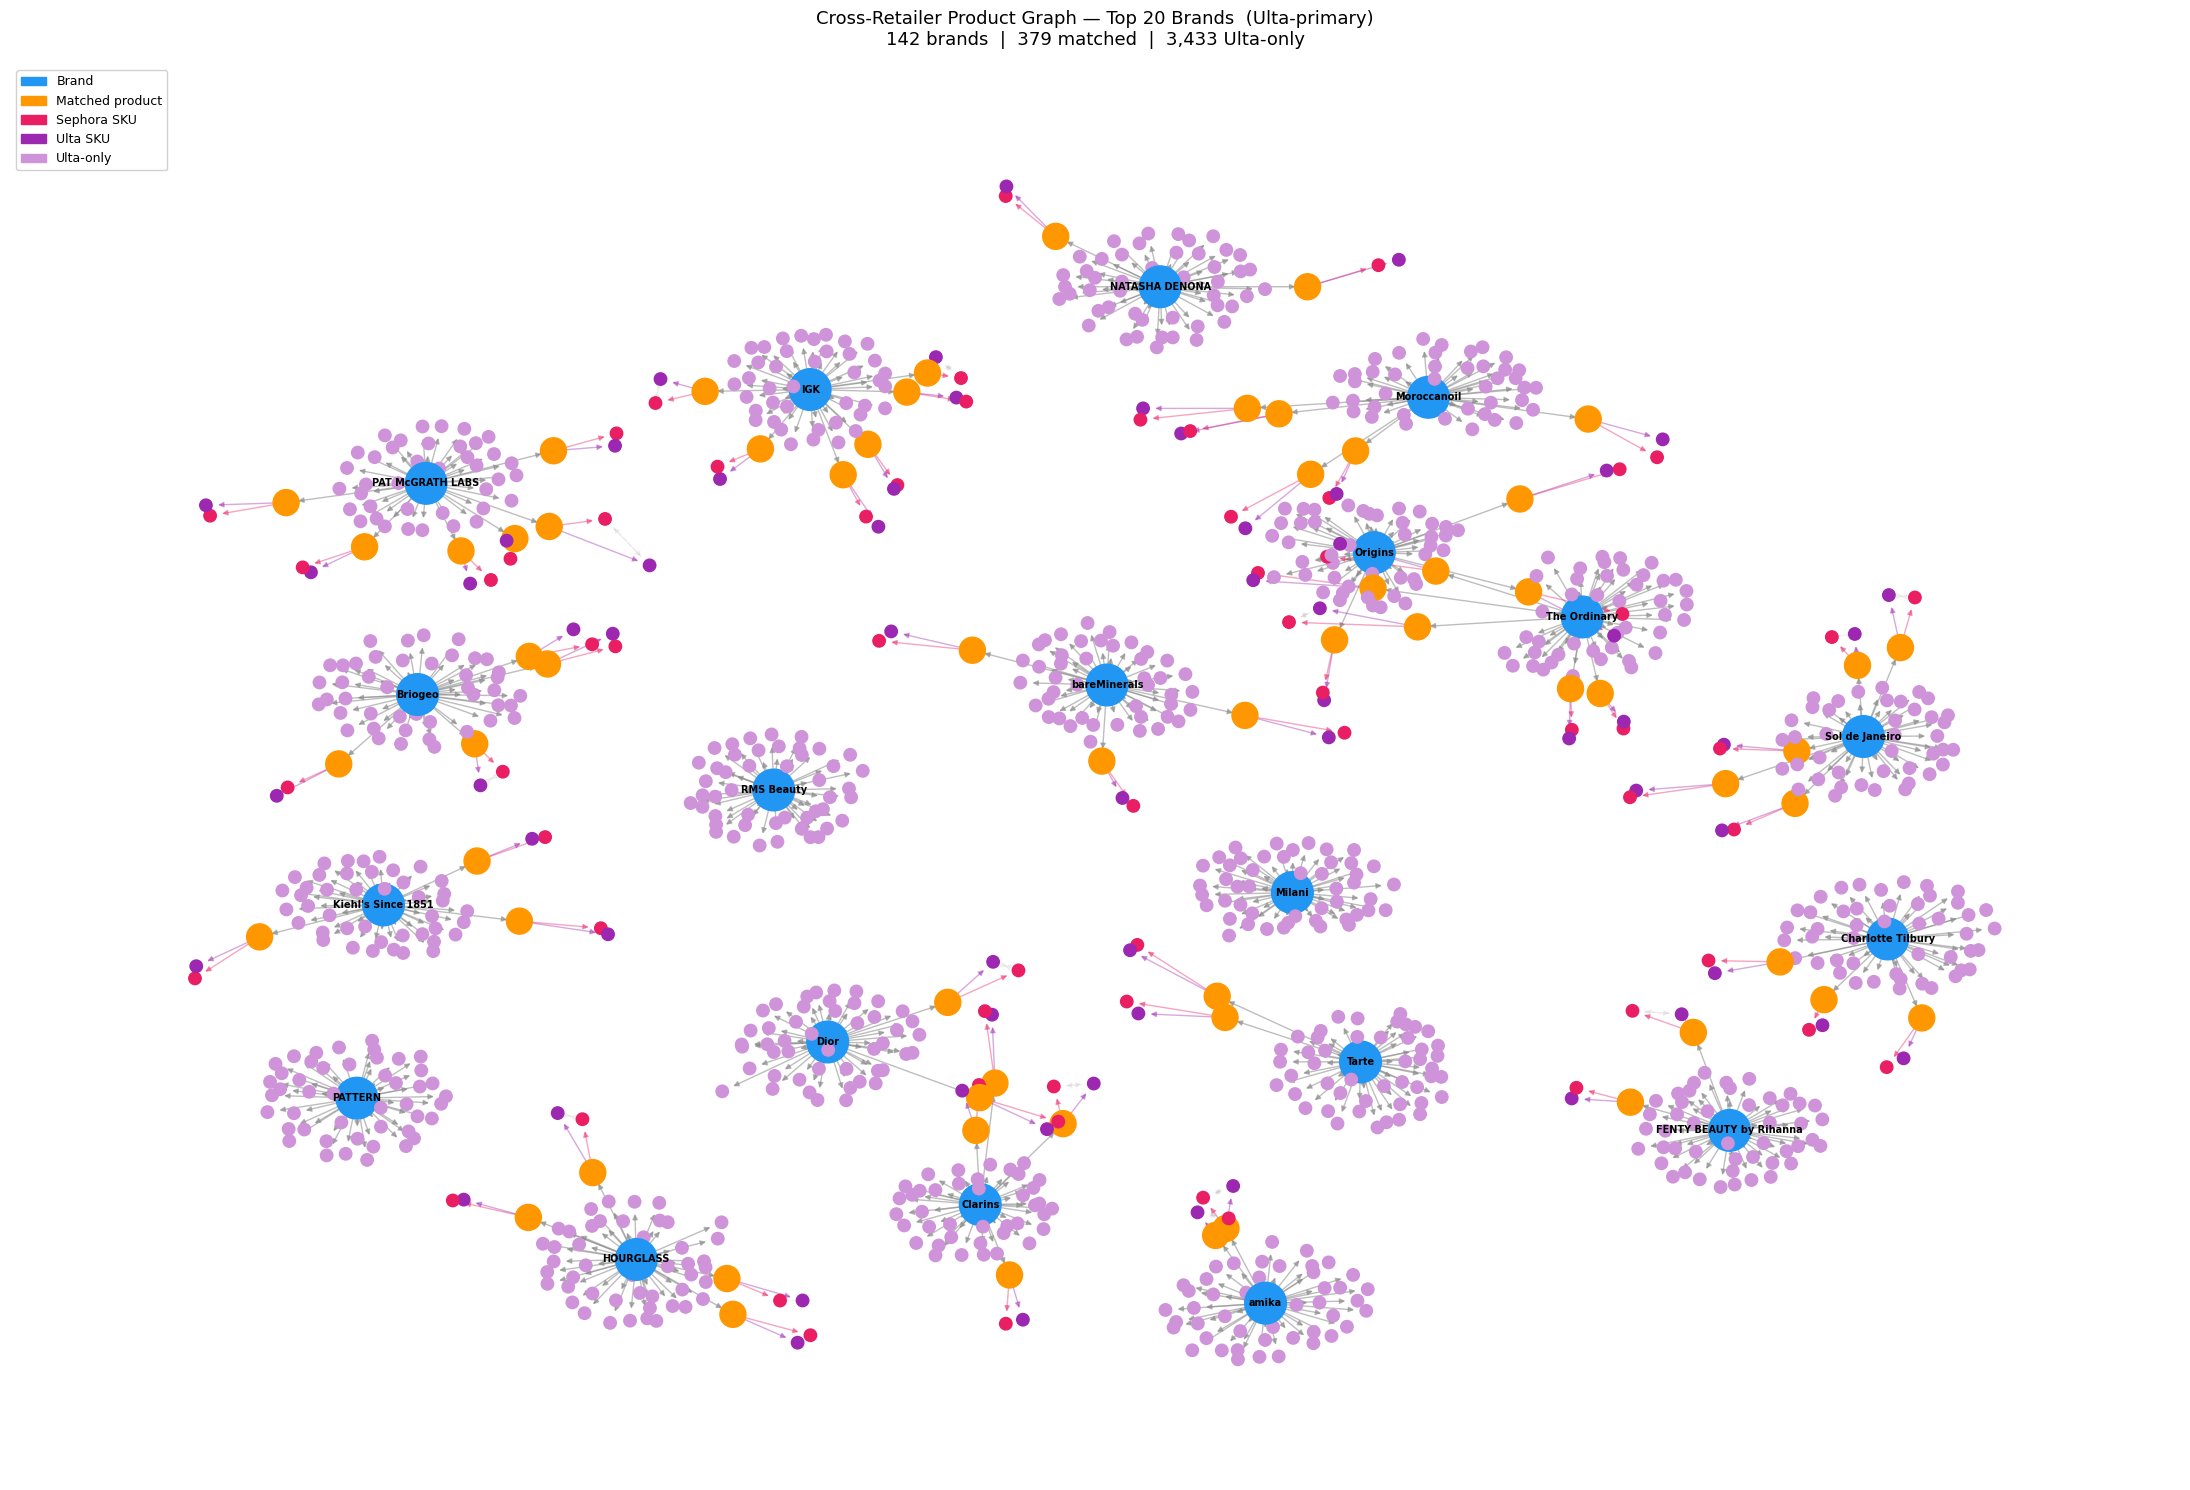

In [4]:
fig = visualize_graph(G, mode="brand_network", top_n=20)
fig.savefig( "outputs/2.1_product_graph_brand_network.png", dpi=150, bbox_inches="tight")

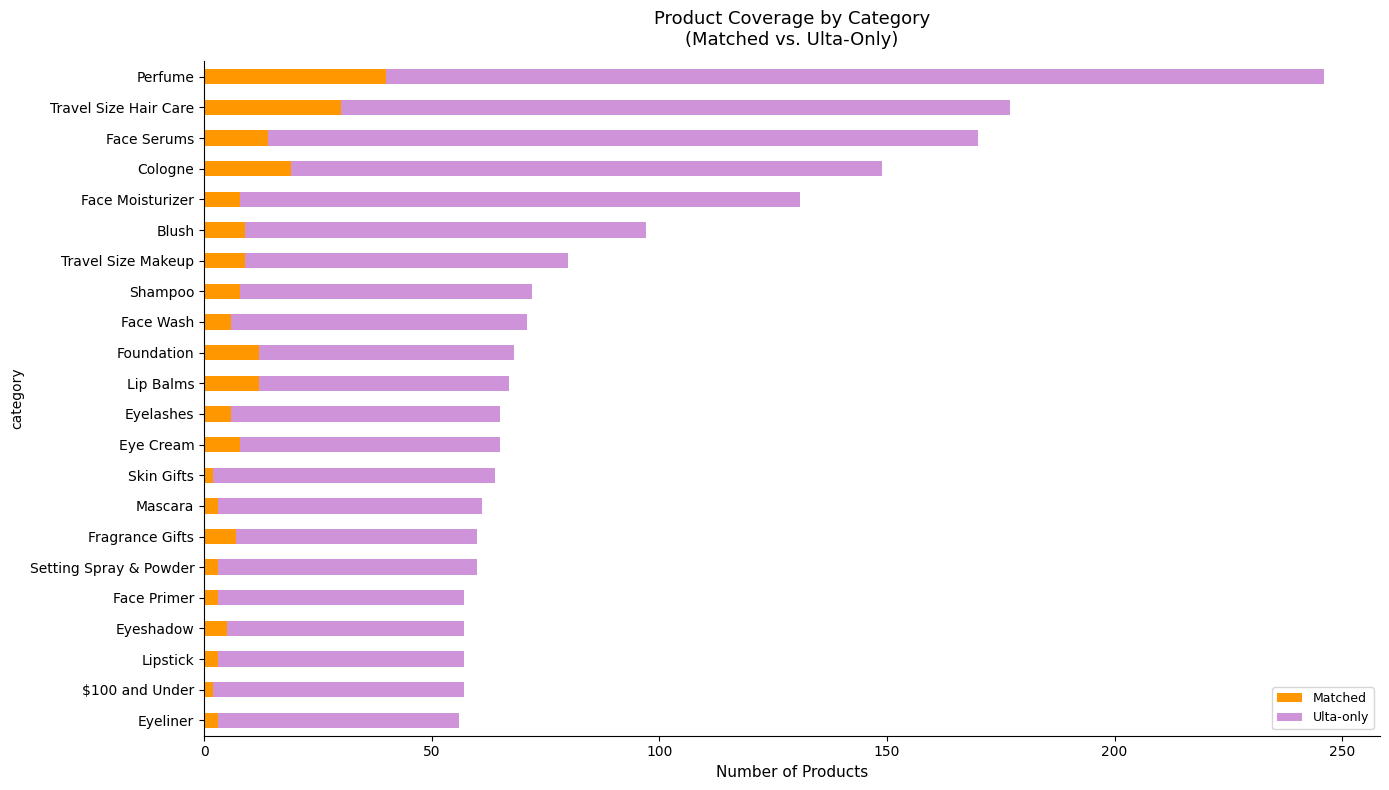

In [5]:
fig = visualize_graph(G, mode="category_heatmap")
fig.savefig( "outputs/2.1_product_graph_category_heatmap.png", dpi=150, bbox_inches="tight")

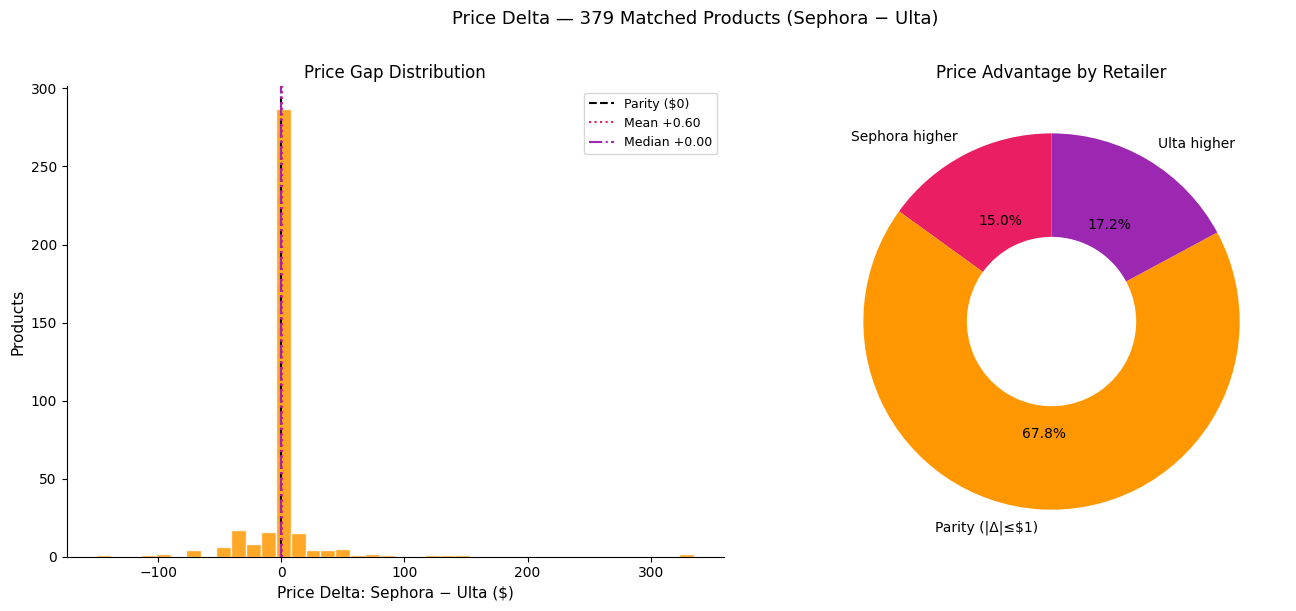

In [6]:
fig = visualize_graph(G, mode="price_delta")
fig.savefig( "outputs/2.1_product_graph_price_delta.png", dpi=150, bbox_inches="tight")

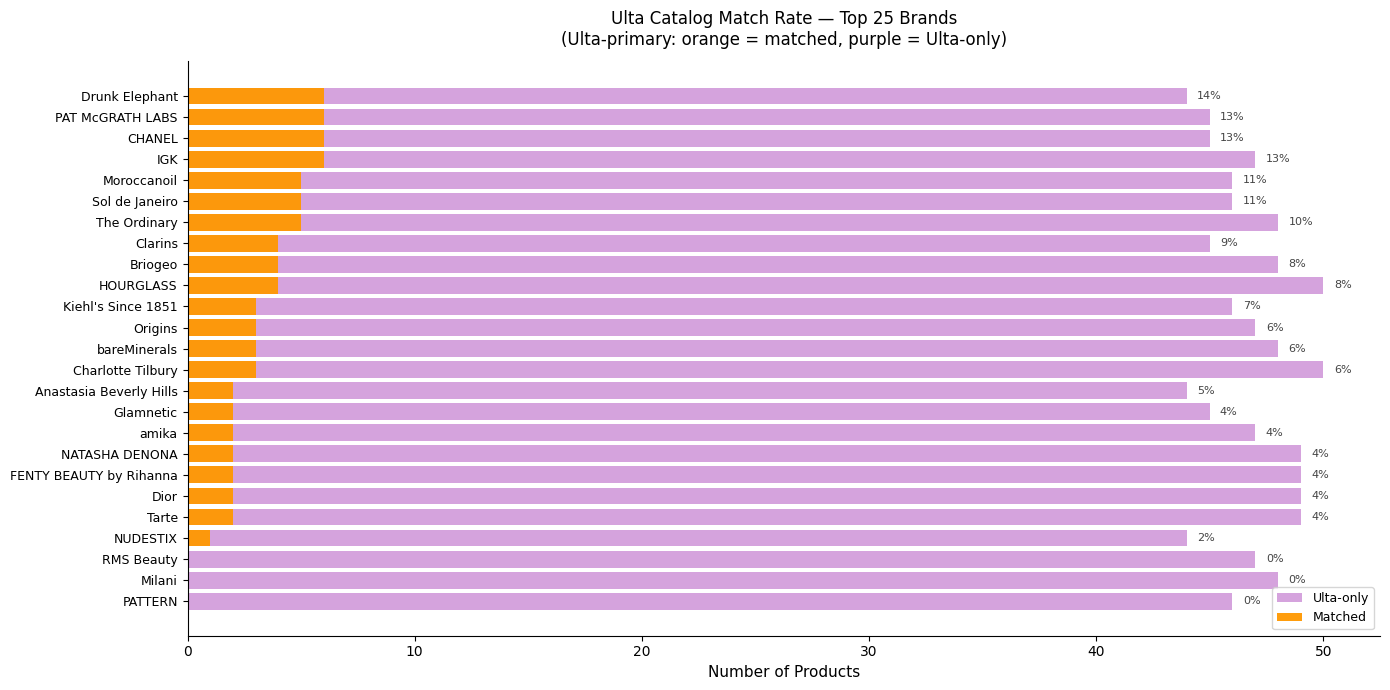

In [7]:
fig = visualize_graph(G, mode="coverage", top_n=25)

In [8]:
fig.savefig("outputs/1.1_product_graph_coverage.png", dpi=150, bbox_inches="tight")

In [10]:
pairs = get_cross_platform_pairs(G)
print(f"{len(pairs):,} matched pairs\n")
print(pairs[["sephora_product_name", "ulta_product_name",
             "sephora_price", "ulta_price", "price_delta",
             "sephora_rating", "ulta_rating", "rating_delta",
             "similarity"]].head(10).to_string(index=False))

379 matched pairs

                                             sephora_product_name                                ulta_product_name  sephora_price  ulta_price  price_delta  sephora_rating  ulta_rating  rating_delta  similarity
                    Perfect Defense Heat Protectant - Moroccanoil         Perfect Defense Heat Protectant - 6.0 oz           32.0        32.0          0.0        4.549985          4.7     -0.150015         1.0
                    All in One Leave-In Conditioner - Moroccanoil                  All in One Leave-In Conditioner           32.0        32.0          0.0        4.533208          4.6     -0.066792         1.0
                                  Hydrating Shampoo - Moroccanoil                       Hydrating Shampoo - 8.5 oz           30.0        30.0          0.0        4.209677          4.3     -0.090323         1.0
                              Hydrating Conditioner - Moroccanoil                   Hydrating Conditioner - 8.5 oz           30.0        30.0

In [11]:
ulta_only = get_ulta_only_products(G)
print(f"{len(ulta_only):,} Ulta-only products (no Sephora match)\n")
print(ulta_only[["brand", "product_name", "category", "price", "rating"]].head(10))

3,433 Ulta-only products (no Sephora match)

           brand                                   product_name  \
0  Ariana Grande   r.e.m. Cherry Eclipse Eau de Parfum - 3.4 oz   
1  Ariana Grande         MOD Blush Eau de Parfum Spray - 3.4 oz   
2  Ariana Grande   LOVENOTES Pink Woods Eau de Parfum - 4.25 oz   
3  Ariana Grande                Cloud 2.0 Intense Eau de Parfum   
4  Ariana Grande            Thank U Next Eau de Parfum - 3.4 oz   
5  Ariana Grande                  R.E.M. Eau de Parfum - 3.4 oz   
6  Ariana Grande         Wicked Elphaba Enchanted Eau de Parfum   
7  Ariana Grande  Sweet Like Candy By Ariana Grande 2-Piece Set   
8  Ariana Grande                   MOD Vanilla Mini 2-Piece Set   
9  Ariana Grande                  Ariana Grande 4-Piece Coffret   

          category  price  rating  
0          Perfume   72.0     4.5  
1          Perfume   72.0     4.3  
2          Perfume   80.0     4.2  
3          Perfume   72.0     4.2  
4          Perfume   72.0     4.0  
5

In [12]:
brand_df = query_brand(G, "charlotte tilbury")   # case-insensitive
print(f"{len(brand_df)} products for Charlotte Tilbury\n")
print(brand_df[["node_type", "product_name", "price", "rating"]].to_string(index=False))

50 products for Charlotte Tilbury

      node_type                                                          product_name  price  rating
matched_product                       Airbrush Flawless Finish Setting Powder - 3 Tan    NaN     NaN
matched_product                                Hollywood Flawless Filter - 4.5 Medium    NaN     NaN
matched_product                                     Lip Cheat Lip Liner - Pillow Talk    NaN     NaN
      ulta_only                              Airbrush Flawless Setting Spray - 3.3 oz   39.0     4.1
      ulta_only                       Airbrush Flawless Blur Concealer - 8 Medium-Tan   36.0     4.7
      ulta_only                                 Airbrush Flawless Foundation - 6 Cool   52.0     4.5
      ulta_only                                Matte Revolution Lipstick - Catwalking   37.0     4.6
      ulta_only                 Magic Cream Moisturizer with Hyaluronic Acid - 1.7 oz  105.0     4.6
      ulta_only                                       Ai

In [13]:
import numpy as np

price_pairs = pairs.dropna(subset=["price_delta"])
arr = price_pairs["price_delta"].values
print(f"Price delta (Sephora − Ulta) across {len(arr):,} matched products:")
print(f"  Mean          : ${arr.mean():+.2f}")
print(f"  Median        : ${np.median(arr):+.2f}")
print(f"  Sephora higher: {(arr > 1).sum():,}  ({(arr > 1).mean()*100:.1f}%)")
print(f"  Ulta higher   : {(arr < -1).sum():,}  ({(arr < -1).mean()*100:.1f}%)")
print(f"  Parity |Δ|≤$1 : {(np.abs(arr) <= 1).sum():,}  ({(np.abs(arr) <= 1).mean()*100:.1f}%)")

Price delta (Sephora − Ulta) across 379 matched products:
  Mean          : $+0.60
  Median        : $+0.00
  Sephora higher: 57  (15.0%)
  Ulta higher   : 65  (17.2%)
  Parity |Δ|≤$1 : 257  (67.8%)


In [14]:
rating_pairs = pairs.dropna(subset=["rating_delta"])
arr = rating_pairs["rating_delta"].values
print(f"Rating delta (Sephora − Ulta) across {len(arr):,} matched products:")
print(f"  Mean          : {arr.mean():+.3f} ★")
print(f"  Median        : {np.median(arr):+.3f} ★")
print(f"  Sephora higher: {(arr > 0).sum():,}  ({(arr > 0).mean()*100:.1f}%)")
print(f"  Ulta higher   : {(arr < 0).sum():,}  ({(arr < 0).mean()*100:.1f}%)")

Rating delta (Sephora − Ulta) across 379 matched products:
  Mean          : -0.114 ★
  Median        : -0.097 ★
  Sephora higher: 122  (32.2%)
  Ulta higher   : 255  (67.3%)


## Cross-Retailer Product Matching: Price and Rating Architecture

### Data Context

The matching exercise identified 379 product-level pairs across 142 shared brands. Sephora's scraper captured a substantially smaller catalog than Ulta's — 3,433 Ulta products from these brands have no Sephora match in the dataset, a disparity that reflects differential scraping coverage rather than genuine catalog exclusivity. The match rate figures and brand-level coverage statistics should not be interpreted as evidence of cross-listing strategy. The 379 matched pairs represent products where both scrapers successfully captured the same SKU, and the analyses in this section are confined to that matched set.

### Price Architecture: Near-Universal Parity

The most operationally significant finding in the matched data is the extreme concentration of pricing at parity. 67.8% of the 379 matched products carry an absolute price difference of $1 or less between platforms, with a median delta of exactly $0.00 and a mean of +$0.60 (Sephora marginally higher). The distribution is sharply concentrated at zero with a small number of outliers in both directions generating the non-zero mean, as visible in the heavy-tailed price gap histogram.

This is an actively managed equilibrium rather than coincidence. Brands maintaining identical prices across Sephora and Ulta for the same SKU are doing so deliberately, consistent with the pricing constraints common in prestige beauty retail. The specific matched pairs confirm the pattern at the product level: Moroccanoil's Perfect Defense Heat Protectant and Hydrating Shampoo both carry identical $32 and $30 price points across platforms; Sunday Riley's CEO Vitamin C Serum is $85 on both; The INKEY List's Advanced Retinal Serum is $15 on both. Across categories — skincare, haircare, and fragrance alike — price parity is the default operating state for cross-listed SKUs.

Of the 32.2% of products showing meaningful price differences, the directional split between Sephora-higher (15.0%, n=57) and Ulta-higher (17.2%, n=65) is nearly balanced, with no systematic platform-level premium in either direction. Individual exceptions exist — Carolina Herrera's Very Good Girl carries an $8 Ulta premium ($184 vs. $176 at Sephora) — but these are product-level anomalies rather than category-level patterns. The near-even split between Sephora-higher and Ulta-higher products means there is no evidence that either platform systematically extracts a premium across the matched catalog.

The implication for the channel-specific pricing recommendations in section 3.6 is that they apply to a minority of the matched catalog. For the 68% of products already at parity, the pricing architecture is either optimally managed or contractually constrained. The actionable population is the 32% with price gaps, which should be audited against the price sensitivity divergence findings: brands in the Sephora-sensitive divergence group that are currently Ulta-higher should evaluate whether the Ulta premium is suppressing velocity consistent with the DiD evidence, while brands in the Ulta-sensitive group that are currently Sephora-higher may be leaving velocity on the table at Sephora without a commensurate quality-signal benefit.

### Rating Architecture: Systematic Ulta Advantage

Unlike pricing, ratings are not managed to parity and the gap is consistent and directional. Ulta rates the same product higher than Sephora on 67.3% of matched pairs, with a mean Sephora disadvantage of −0.114 stars and a median of −0.097 stars. The gap is not driven by outliers — the near-identical mean and median confirm a stable, symmetric distribution of Sephora underperformance across the matched catalog.

The matched product examples illustrate the pattern concretely across multiple brands and categories. Moroccanoil's Perfect Defense Heat Protectant carries 4.55 stars on Sephora and 4.70 on Ulta; the Hydrating Conditioner scores 4.49 on Sephora and 4.60 on Ulta; Sunday Riley's CEO Vitamin C Serum shows the largest gap in the visible sample at 4.12 on Sephora versus 4.50 on Ulta — a 0.38-star difference on an identical product. The INKEY List's Advanced Retinal Serum is the one exception in the sample going the other direction (4.86 Sephora vs. 4.80 Ulta), but this direction is the minority case.

Two mechanisms explain the systematic gap. First, Sephora's consumer base applies stricter evaluation standards — these are more engaged, more category-informed consumers with a broader prestige reference set, more likely to penalize products that underperform relative to category peers. Second, Sephora's stronger negative review propagation documented in section 3.5 — a rating ATT of −0.328 stars at Sephora versus −0.263 at Ulta — means that negative events leave more persistent residual signal in Sephora's rating distributions over time. The combined effect is that the same product accumulates a structurally lower average rating at Sephora than at Ulta across its review lifecycle, not because of product performance differences but because of platform-level evaluation dynamics.

The practical consequence for brand management is that Sephora and Ulta ratings for the same SKU should not be directly compared as quality signals. A product at 4.2 stars on Sephora and 4.4 stars on Ulta is receiving equivalent consumer satisfaction signals adjusted for platform baseline — the 0.2-star gap reflects the platform differential documented here, not a product issue. The correct benchmark in each case is performance relative to the platform-specific category distribution. A product consistently above its Sephora category median is performing well regardless of absolute star count; a product below its Ulta category median warrants attention regardless of whether the absolute rating looks acceptable by general standards. Conflating the two scales when setting rating-improvement targets or allocating quality remediation resources will systematically over-invest in Sephora products that are performing normally for their platform context.